In [1]:
#required libraries

!pip install pandas
!pip install numpy==1.26.4
!pip install scikit-surprise
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install scikit-surprise
!pip install tensorflow
!pip install lime
!pip install shap


  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554977 sha256=731ee1b2570412f6d8e8a115df6ac6e7e185e8a652df013f1db2a129fc96e965
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cc6547dc66487ea7b5a8717bcefeee339c7d9350b4dab9faa2ebc2b9d1f57db3
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.6 MB/s eta 0:00:00
   ━━━

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:


import pandas as pd
import numpy as np


movies = pd.read_csv("dataset/movies.csv")
ratings = pd.read_csv("dataset/ratings.csv")
tags = pd.read_csv("dataset/tags.csv")
links = pd.read_csv("dataset/links.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)
Tags shape: (3683, 4)
Links shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
print("Movies Dataset")
print(movies.head())

print("\nRatings Dataset")
print(ratings.head())

Movies Dataset
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings Dataset
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [ ]:
# Importing TF-IDF and cosine similarity tools

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# Replacing '|' with spaces so TF-IDF treats genres as words
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 23)


In [ ]:
# cosine similarity between all movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Check similarity matrix shape
print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (9742, 9742)


In [ ]:
# mapping from movie title to index

indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()
print(indices['Toy Story (1995)'])

0


In [11]:
def recommend_movies(title, top_n=5):

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) # Sort by similarity score
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]

    recommendations = movies[['title']].iloc[movie_indices]
    recommendations['similarity_score'] = [i[1] for i in sim_scores]

    return recommendations

In [12]:
recommend_movies("Toy Story (1995)", 5)

,title,similarity_score
1706,Antz (1998),1.0
2355,Toy Story 2 (1999),1.0
2809,"Adventures of Rocky and Bullwinkle, The (2000)",1.0
3000,"Emperor's New Groove, The (2000)",1.0
3568,"Monsters, Inc. (2001)",1.0


In [13]:
recommend_movies("Jumanji (1995)", 5)

,title,similarity_score
53,"Indian in the Cupboard, The (1995)",1.0
109,"NeverEnding Story III, The (1994)",1.0
767,Escape to Witch Mountain (1975),1.0
1514,Darby O'Gill and the Little People (1959),1.0
1556,Return to Oz (1985),1.0


In [ ]:
# user profile from rated movies

def build_user_profile(user_id):

    user_ratings = ratings[ratings['userId'] == user_id]
    user_movies = user_ratings.merge(movies, on='movieId')

    # movie indices from the movies dataframe
    movie_indices = movies[movies['movieId'].isin(user_movies['movieId'])].index

    # TF-IDF vectors for those movies
    user_tfidf = tfidf_matrix[movie_indices]
    user_weights = user_movies['rating'].values.reshape(-1,1)

    weighted_tfidf = user_tfidf.multiply(user_weights)

    user_profile = weighted_tfidf.sum(axis=0) / user_weights.sum()

    user_profile = np.asarray(user_profile)

    return user_profile

In [15]:
# Recommend movies for a user based on user profile

def recommend_movies_for_user(user_id, top_n=5):

    user_profile = build_user_profile(user_id)

    similarity_scores = cosine_similarity(user_profile, tfidf_matrix)

    sim_scores = list(enumerate(similarity_scores[0]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    rated_movies = ratings[ratings['userId'] == user_id]['movieId']
    rated_indices = movies[movies['movieId'].isin(rated_movies)].index

    sim_scores = [i for i in sim_scores if i[0] not in rated_indices]

    sim_scores = sim_scores[:top_n]

    movie_indices = [i[0] for i in sim_scores]

    recommendations = movies[['title']].iloc[movie_indices]
    recommendations['similarity_score'] = [i[1] for i in sim_scores]

    return recommendations

In [16]:
recommend_movies_for_user(1, 5)

,title,similarity_score
8597,Dragonheart 2: A New Beginning (2000),0.791026
6570,"Hunting Party, The (2007)",0.773645
4005,Flashback (1990),0.773089
4681,The Great Train Robbery (1978),0.773089
4409,Charlie's Angels: Full Throttle (2003),0.760503


In [ ]:
# user-movie rating matrix

user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix = user_movie_matrix.fillna(0) # missing val;ues with 0

print("User-Movie Matrix Shape:", user_movie_matrix.shape)
user_movie_matrix.head()

User-Movie Matrix Shape: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# similarity between users

user_similarity = cosine_similarity(user_movie_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [ ]:
# Predict ratings using User-Based Collaborative Filtering

def predict_ratings_user_based(user_id, top_k=10):

    user_similarities = user_similarity_df[user_id]
    similar_users = user_similarities.sort_values(ascending=False)[1:top_k+1]
    similar_user_ratings = user_movie_matrix.loc[similar_users.index]
    weighted_ratings = np.dot(similar_users.values, similar_user_ratings)
    similarity_sum = np.sum(np.abs(similar_users.values))
    predicted_ratings = weighted_ratings / similarity_sum
    predicted_ratings = pd.Series(predicted_ratings, index=user_movie_matrix.columns)

    return predicted_ratings

In [ ]:
# Recommend movies for user based on predicted ratings

def recommend_user_based(user_id, top_n=5):

    predicted_ratings = predict_ratings_user_based(user_id)
    rated_movies = user_movie_matrix.loc[user_id]
    rated_movies = rated_movies[rated_movies > 0].index

    # Remove already rated movies
    predicted_ratings = predicted_ratings.drop(rated_movies)

    # top recommendations
    top_movies = predicted_ratings.sort_values(ascending=False).head(top_n)
    recommendations = movies[movies['movieId'].isin(top_movies.index)][['title']]
    recommendations['predicted_rating'] = top_movies.values
    return recommendations

In [21]:
recommend_user_based(1,5)

,title,predicted_rating
507,Terminator 2: Judgment Day (1991),4.195979
659,"Godfather, The (1972)",4.119903
902,Aliens (1986),3.971041
1211,"Hunt for Red October, The (1990)",3.957980
2078,"Sixth Sense, The (1999)",3.885992


In [ ]:
# Compute item-item similarity matrix

item_similarity = cosine_similarity(user_movie_matrix.T)

# Convert to dataframe
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

print("Item similarity matrix shape:", item_similarity_df.shape)
item_similarity_df.head()

Item similarity matrix shape: (9724, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Item-Based Collaborative Filtering Recommender

def recommend_item_based(user_id, top_n=5):

    # movies rated by the user
    user_ratings = user_movie_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]
    scores = {}

    for movie_id, rating in rated_movies.items():

        similar_movies = item_similarity_df[movie_id]

        for sim_movie, similarity in similar_movies.items():

            if sim_movie not in rated_movies.index:

                if sim_movie not in scores:
                    scores[sim_movie] = 0

                scores[sim_movie] += similarity * rating

    # to dataframe
    scores_df = pd.DataFrame(scores.items(), columns=['movieId','score'])
    scores_df = scores_df.sort_values(by='score', ascending=False)
    top_movies = scores_df.head(top_n)
    recommendations = movies[movies['movieId'].isin(top_movies['movieId'])][['title']]
    recommendations['score'] = top_movies['score'].values

    return recommendations

In [24]:
recommend_item_based(1,5)

,title,score
793,Die Hard (1988),352.684010
902,Aliens (1986),330.949884
1158,"Fifth Element, The (1997)",328.180507
1445,"Breakfast Club, The (1985)",326.437374
2195,Ferris Bueller's Day Off (1986),323.117648


In [ ]:
# Prepare rating matrix for SVD

R = user_movie_matrix.values
print("Rating matrix shape:", R.shape)

Rating matrix shape: (610, 9724)


In [ ]:
# Apply Singular Value Decomposition

from scipy.sparse.linalg import svds
k = 50
U, sigma, Vt = svds(R, k=k)
print("U shape:", U.shape)
print("Sigma shape:", sigma.shape)
print("Vt shape:", Vt.shape)

U shape: (610, 50)
Sigma shape: (50,)
Vt shape: (50, 9724)


In [ ]:
# sigma to diagonal matrix
sigma = np.diag(sigma)
predicted_ratings = np.dot(np.dot(U, sigma), Vt)

# To dataframe
predicted_ratings_df = pd.DataFrame(
    predicted_ratings,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.columns
)

predicted_ratings_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,2.181872,0.393674,0.838186,-0.082365,-0.546279,2.521662,-0.887231,-0.025221,0.196969,1.606758,...,-0.024984,-0.021415,-0.028553,-0.028553,-0.024984,-0.028553,-0.024984,-0.024984,-0.024984,-0.058988
2,0.209809,0.004821,0.030742,0.017252,0.183764,-0.060660,0.083306,0.023797,0.048100,-0.151968,...,0.018895,0.016196,0.021594,0.021594,0.018895,0.021594,0.018895,0.018895,0.018895,0.031966
3,0.013394,0.034726,0.050525,0.000200,-0.005577,0.114673,-0.007461,0.000738,0.004747,-0.061284,...,-0.001612,-0.001382,-0.001843,-0.001843,-0.001612,-0.001843,-0.001612,-0.001612,-0.001612,-0.000530
4,2.012072,-0.394882,-0.290386,0.093864,0.123312,0.259765,0.472667,0.035965,0.011293,-0.021983,...,0.001966,0.001685,0.002247,0.002247,0.001966,0.002247,0.001966,0.001966,0.001966,-0.021462
5,1.336714,0.772954,0.064577,0.113880,0.274994,0.584480,0.251048,0.131534,-0.086310,1.035361,...,-0.004407,-0.003778,-0.005037,-0.005037,-0.004407,-0.005037,-0.004407,-0.004407,-0.004407,-0.006099


In [ ]:
# SVD-based recommender

def recommend_svd(user_id, top_n=5):

    user_row = predicted_ratings_df.loc[user_id]
    rated_movies = user_movie_matrix.loc[user_id]
    rated_movies = rated_movies[rated_movies > 0].index
    recommendations = user_row.drop(rated_movies)
    top_movies = recommendations.sort_values(ascending=False).head(top_n)

    result = movies[movies['movieId'].isin(top_movies.index)][['title']]

    result['predicted_rating'] = top_movies.values

    return result

In [29]:
recommend_svd(1,5)

,title,predicted_rating
659,"Godfather, The (1972)",4.009045
793,Die Hard (1988),3.303897
922,"Godfather: Part II, The (1974)",3.303409
1067,Jaws (1975),2.869847
1445,"Breakfast Club, The (1985)",2.859630


In [30]:
import numpy as np
import sys

print("NumPy version:", np.__version__)
print("NumPy location:", np.__file__)
print("Python version:", sys.version)

NumPy version: 1.26.4
NumPy location: /usr/local/lib/python3.12/dist-packages/numpy/__init__.py
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
# degrading numpy version for Surprise compatibility

!pip uninstall -y numpy scikit-surprise

!pip install numpy==1.26.4
!pip install scikit-surprise --no-cache-dir
!pip install scikit-learn pandas matplotlib seaborn

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, bu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 98.7 MB/s eta 0:00:00
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user
^C


In [31]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
!pip install scikit-surprise

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


In [32]:
from surprise import Dataset
from surprise import Reader
from surprise.model_selection import train_test_split
from surprise import SVD
from surprise import accuracy

print("Surprise imported successfully")

Surprise imported successfully


In [33]:
# Prepare data for Surprise

reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']],
    reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Dataset prepared for Surprise.")

Dataset prepared for Surprise.


In [ ]:
# Training SVD model

svd_model = SVD()
svd_model.fit(trainset)
print("SVD model trained.")

SVD model trained.


In [ ]:

predictions = svd_model.test(testset)
rmse = accuracy.rmse(predictions)

print("RMSE:", rmse)

RMSE: 0.8784
RMSE: 0.878413206085512


In [ ]:
# Recommend movies using Surprise SVD

def recommend_surprise(user_id, top_n=5):

    movie_ids = movies['movieId'].unique()
    predictions = []
    for movie_id in movie_ids:
        pred = svd_model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)
    top_movies = predictions[:top_n]
    movie_ids = [i[0] for i in top_movies]
    result = movies[movies['movieId'].isin(movie_ids)][['title']]
    result['predicted_rating'] = [i[1] for i in top_movies]

    return result

In [37]:
recommend_surprise(1,5)

,title,predicted_rating
46,"Usual Suspects, The (1995)",5
277,"Shawshank Redemption, The (1994)",5
314,Forrest Gump (1994),5
596,Ghost in the Shell (Kôkaku kidôtai) (1995),5
602,Dr. Strangelove or: How I Learned to Stop Worr...,5


In [38]:
# Content-based score using TF-IDF similarity

def get_cbf_score(user_id, movie_id):

    # Movies rated by the user
    user_rated = ratings[ratings['userId'] == user_id]

    scores = []

    for _, row in user_rated.iterrows():

        rated_movie_id = row['movieId']

        # Get index positions
        if rated_movie_id in movies['movieId'].values and movie_id in movies['movieId'].values:

            idx1 = movies[movies['movieId'] == rated_movie_id].index[0]
            idx2 = movies[movies['movieId'] == movie_id].index[0]

            sim = cosine_sim[idx1][idx2]

            scores.append(sim * row['rating'])

    if len(scores) == 0:
        return 0

    return sum(scores) / len(scores)

In [ ]:
# Hybrid Recommender

def recommend_hybrid(user_id, top_n=5, alpha=0.5):

    # top CF predictions first
    predictions = []

    for movie_id in movies['movieId']:
        pred = svd_model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    
    predictions.sort(key=lambda x: x[1], reverse=True)

    
    candidate_movies = predictions[:200]

    hybrid_scores = []

    for movie_id, cf_score in candidate_movies:

        cbf_score = get_cbf_score(user_id, movie_id)

        final_score = alpha * cbf_score + (1 - alpha) * cf_score

        hybrid_scores.append((movie_id, final_score))

    hybrid_scores.sort(key=lambda x: x[1], reverse=True)
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    results = []
    for movie_id, score in hybrid_scores:
        if movie_id not in rated_movies:
            results.append((movie_id, score))
        if len(results) == top_n:
            break

    movie_ids = [x[0] for x in results]
    scores = [x[1] for x in results]
    recommendations = movies[movies['movieId'].isin(movie_ids)][['title']]
    recommendations['hybrid_score'] = scores

    return recommendations

In [42]:
recommend_hybrid(1,5)

,title,hybrid_score
924,"Grand Day Out with Wallace and Gromit, A (1989)",3.194852
3194,Shrek (2001),3.171024
4176,City of God (Cidade de Deus) (2002),3.093065
4348,Laputa: Castle in the Sky (Tenkû no shiro Rapy...,3.077857
4800,"Lord of the Rings: The Return of the King, The...",3.077642


In [43]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Extract movie features


movie_genres = movies['genres'].str.get_dummies(sep=' ')

movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

movies['year'] = movies['year'].fillna(movies['year'].median())

movies['year'] = (movies['year'] - movies['year'].min()) / (movies['year'].max() - movies['year'].min())

avg_rating = ratings.groupby('movieId')['rating'].mean()

movies = movies.merge(avg_rating, on='movieId', how='left')
movies['rating'] = movies['rating'].fillna(movies['rating'].mean())

movies['rating'] = (movies['rating'] - movies['rating'].min()) / (movies['rating'].max() - movies['rating'].min())

print("Movie features prepared")
movies.head()

Movie features prepared


,movieId,title,genres,year,rating
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,0.801724,0.760207
1,2,Jumanji (1995),Adventure Children Fantasy,0.801724,0.651515
2,3,Grumpier Old Men (1995),Comedy Romance,0.801724,0.613248
3,4,Waiting to Exhale (1995),Comedy Drama Romance,0.801724,0.412698
4,5,Father of the Bride Part II (1995),Comedy,0.801724,0.571429


In [45]:
# Combine movie features

movie_features = pd.concat(
    [movie_genres, movies[['year','rating']]],
    axis=1
)

print("Movie feature matrix shape:", movie_features.shape)
movie_features.head()

Movie feature matrix shape: (9742, 24)


,(no,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,genres,listed),year,rating
0,0,0,1,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0.801724,0.760207
1,0,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0.801724,0.651515
2,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0.801724,0.613248
3,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0.801724,0.412698
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0.801724,0.571429


In [46]:
# Compute user genre preferences

user_genre_pref = ratings.merge(movies[['movieId','genres']], on='movieId')

user_genre_pref = user_genre_pref.assign(
    genres=user_genre_pref['genres'].str.split(' ')
).explode('genres')

user_genre_pref = user_genre_pref.pivot_table(
    index='userId',
    columns='genres',
    values='rating',
    aggfunc='mean'
).fillna(0)

print("User feature matrix shape:", user_genre_pref.shape)
user_genre_pref.head()

User feature matrix shape: (610, 22)


genres,(no,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,genres,listed)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,4.322222,4.388235,4.689655,4.547619,4.277108,4.355556,0.000000,4.529412,4.297872,...,0.000000,4.681818,4.166667,4.307692,4.225000,4.145455,4.500000,4.285714,0.0,0.0
2,0.0,3.954545,4.166667,0.000000,0.000000,4.000000,3.800000,4.333333,3.882353,0.000000,...,3.750000,0.000000,4.000000,4.500000,3.875000,3.700000,4.500000,3.500000,0.0,0.0
3,0.0,3.571429,2.727273,0.500000,0.500000,1.000000,0.500000,0.000000,0.750000,3.375000,...,0.000000,0.500000,5.000000,0.500000,4.200000,4.142857,0.500000,0.000000,0.0,0.0
4,0.0,3.320000,3.655172,4.000000,3.800000,3.509615,3.814815,4.000000,3.483333,3.684211,...,3.000000,4.000000,3.478261,3.379310,2.833333,3.552632,3.571429,3.800000,0.0,0.0
5,0.0,3.111111,3.250000,4.333333,4.111111,3.466667,3.833333,0.000000,3.800000,4.142857,...,3.666667,4.400000,4.000000,3.090909,2.500000,3.555556,3.333333,3.000000,0.0,0.0


In [ ]:
# training dataset correctly

data = ratings.merge(
    movies[['movieId']],
    on='movieId'
)

user_features = user_genre_pref.loc[data['userId']].values

movie_feature_lookup = movie_features.set_index(movies['movieId'])

movie_features_array = movie_feature_lookup.loc[data['movieId']].values

y = data['rating'].values # target varible

print("Training data prepared")

print("User features shape:", user_features.shape)
print("Movie features shape:", movie_features_array.shape)
print("Target shape:", y.shape)

Training data prepared
User features shape: (100836, 22)
Movie features shape: (100836, 24)
Target shape: (100836,)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate


user_input = Input(shape=(user_features.shape[1],))

user_dense = Dense(64, activation='relu')(user_input)
user_embedding = Dense(32, activation='relu')(user_dense)

# Movie input
movie_input = Input(shape=(movie_features.shape[1],))

movie_dense = Dense(64, activation='relu')(movie_input)
movie_embedding = Dense(32, activation='relu')(movie_dense)


merged = Concatenate()([user_embedding, movie_embedding])

dense1 = Dense(64, activation='relu')(merged)
dense2 = Dense(32, activation='relu')(dense1)

output = Dense(1)(dense2)

model = Model(inputs=[user_input, movie_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      1,472 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      1,600 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64)        │          0 │ dense_8[0][0],    │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      4,160 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      2,080 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         33 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(
    [user_features, movie_features_array],
    y,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.8458 - mae: 0.7060 - val_loss: 0.6571 - val_mae: 0.6154
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6722 - mae: 0.6300 - val_loss: 0.6444 - val_mae: 0.6003
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6602 - mae: 0.6230 - val_loss: 0.6400 - val_mae: 0.6048
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6552 - mae: 0.6205 - val_loss: 0.6397 - val_mae: 0.6015
Epoch 5/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6527 - mae: 0.6194 - val_loss: 0.6329 - val_mae: 0.6005
Epoch 6/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6506 - mae: 0.6186 - val_loss: 0.6442 - val_mae: 0.6100
Epoch 7/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6425 - mae: 0.6142 - val_loss: 0.6252 - val_mae: 0.5958
Epoch 8/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6393 - mae: 0.6134 - val_loss: 0.6271 - val_mae: 0.5957
Epoch 9/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - l

In [55]:
predictions = model.predict([user_features[:10], movie_features_array[:10]])
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
[[4.6843295]
 [4.044236 ]
 [4.602973 ]
 [4.506535 ]
 [4.6543307]
 [4.136813 ]
 [4.422006 ]
 [4.64093  ]
 [4.3440566]
 [3.7396078]]


In [ ]:


rl_data = ratings.copy()


rl_data['reward'] = rl_data['rating'].apply(lambda x: 1 if x >= 4 else 0)

print("RL dataset ready")
rl_data.head()

RL dataset ready


,userId,movieId,rating,timestamp,reward
0,1,1,4.0,964982703,1
1,1,3,4.0,964981247,1
2,1,6,4.0,964982224,1
3,1,47,5.0,964983815,1
4,1,50,5.0,964982931,1


In [ ]:
import numpy as np



class EpsilonGreedyBandit:

    def __init__(self, epsilon=0.1):
        self.epsilon = epsilon
        self.movie_rewards = {}
        self.movie_counts = {}

    def choose_movie(self, movie_list):

        if np.random.rand() < self.epsilon:
            return np.random.choice(movie_list)

        avg_rewards = {
            m: self.movie_rewards.get(m,0)/self.movie_counts.get(m,1)
            for m in movie_list
        }

        return max(avg_rewards, key=avg_rewards.get)

    def update(self, movie, reward):

        if movie not in self.movie_rewards:
            self.movie_rewards[movie] = 0
            self.movie_counts[movie] = 0

        self.movie_rewards[movie] += reward
        self.movie_counts[movie] += 1

In [ ]:
# bandit simulation using sample data

bandit = EpsilonGreedyBandit(epsilon=0.1)

movies_list = rl_data['movieId'].unique()


sample_data = rl_data.sample(5000, random_state=42)

for _, row in sample_data.iterrows():

    movie = row['movieId']
    reward = row['reward']

    chosen_movie = bandit.choose_movie(movies_list)

    bandit.update(chosen_movie, reward)

print("Bandit training complete")

Bandit training complete


In [ ]:
# average rewards

avg_rewards = {
    m: bandit.movie_rewards.get(m,0)/bandit.movie_counts.get(m,1)
    for m in movies_list
}

# Get top movies
top_bandit = sorted(avg_rewards.items(), key=lambda x:x[1], reverse=True)[:5]

top_ids = [x[0] for x in top_bandit]

movies[movies['movieId'].isin(top_ids)][['title']]

,title
4522,Dickie Roberts: Former Child Star (2003)
5110,Gladiator (1992)
6196,American Dreamz (2006)
7223,Leap Year (2010)
7487,"Company Men, The (2010)"


In [ ]:
# the Q-learning recommender

class QLearningRecommender:

    def __init__(self, alpha=0.1, gamma=0.9):
        self.alpha = alpha
        self.gamma = gamma
        self.Q = {}

    def update(self, state, action, reward):

        if (state, action) not in self.Q:
            self.Q[(state, action)] = 0

        max_future = max(
            [self.Q.get((state,a),0) for a in range(5)],
            default=0
        )

        self.Q[(state, action)] += self.alpha * (
            reward + self.gamma*max_future - self.Q[(state, action)]
        )

In [64]:
# Train Q-learning

q_agent = QLearningRecommender()

for _, row in rl_data.iterrows():

    state = row['userId']
    action = row['movieId']
    reward = row['reward']

    q_agent.update(state, action, reward)

print("Q-learning training complete")

Q-learning training complete


In [ ]:
# Feature-based 

def explain_content(movie_title):

    movie = movies[movies['title']==movie_title]

    genres = movie['genres'].values[0]

    print(f"This movie was recommended because it belongs to genres: {genres}")

explain_content("Toy Story (1995)")

This movie was recommended because it belongs to genres: Adventure Animation Children Comedy Fantasy


In [ ]:
# Neighborhood-based 

def explain_cf(movie_title):

    idx = indices[movie_title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x:x[1], reverse=True)[1:6]

    movie_indices = [i[0] for i in sim_scores]

    similar_movies = movies['title'].iloc[movie_indices]

    print("members who liked this movie also liked:")

    for m in similar_movies:
        print(m)

explain_cf("Toy Story (1995)")

Users who liked this movie also liked:
- Antz (1998)
- Toy Story 2 (1999)
- Adventures of Rocky and Bullwinkle, The (2000)
- Emperor's New Groove, The (2000)
- Monsters, Inc. (2001)


In [ ]:
import shap

# Create background samples
background_user = user_features[:100]
background_movie = movie_features_array[:100]

explainer = shap.DeepExplainer(
    model,
    [background_user, background_movie]
)

shap_values = explainer.shap_values(
    [user_features[:10], movie_features_array[:10]]
)

print("SHAP explanation computed")

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


SHAP explanation computed


/tmp/ipykernel_15194/1970138671.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[0], user_features[:10])
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:733: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim((slow, shigh))


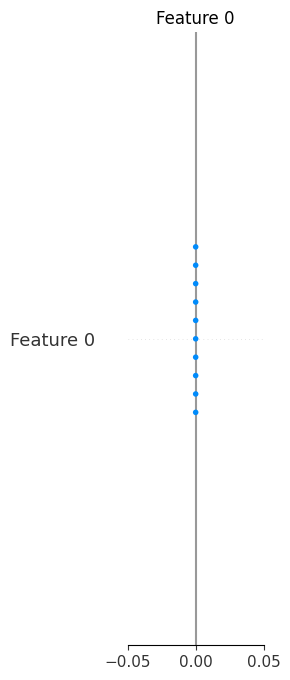

In [69]:
# Visualize feature importance

shap.summary_plot(shap_values[0], user_features[:10])

In [ ]:
# Simple feature

importance = np.abs(model.get_weights()[0]).mean(axis=1)

feature_names = user_genre_pref.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance[:len(feature_names)]
})

importance_df.sort_values(by="importance", ascending=False).head(10)

,feature,importance
1,Action,0.150564
16,Sci-Fi,0.149759
0,(no,0.149312
10,Film-Noir,0.148059
5,Comedy,0.144917
15,Romance,0.141188
14,Mystery,0.140238
6,Crime,0.139555
20,genres,0.138510
8,Drama,0.138386


**the Recommendations are made.**

Feature-based explanations show the genres contributing to recommend actions.
Neighborhood explanations highlight similar movies or users.
Model-agnostic explanations (SHAP) reveal how features influence neural network predictions.